In [11]:
from IPython.display import Image

import numpy as np 
import pandas as pd
import math
import matplotlib.pyplot as plt 
import scipy.optimize
import matplotlib.pyplot as plt

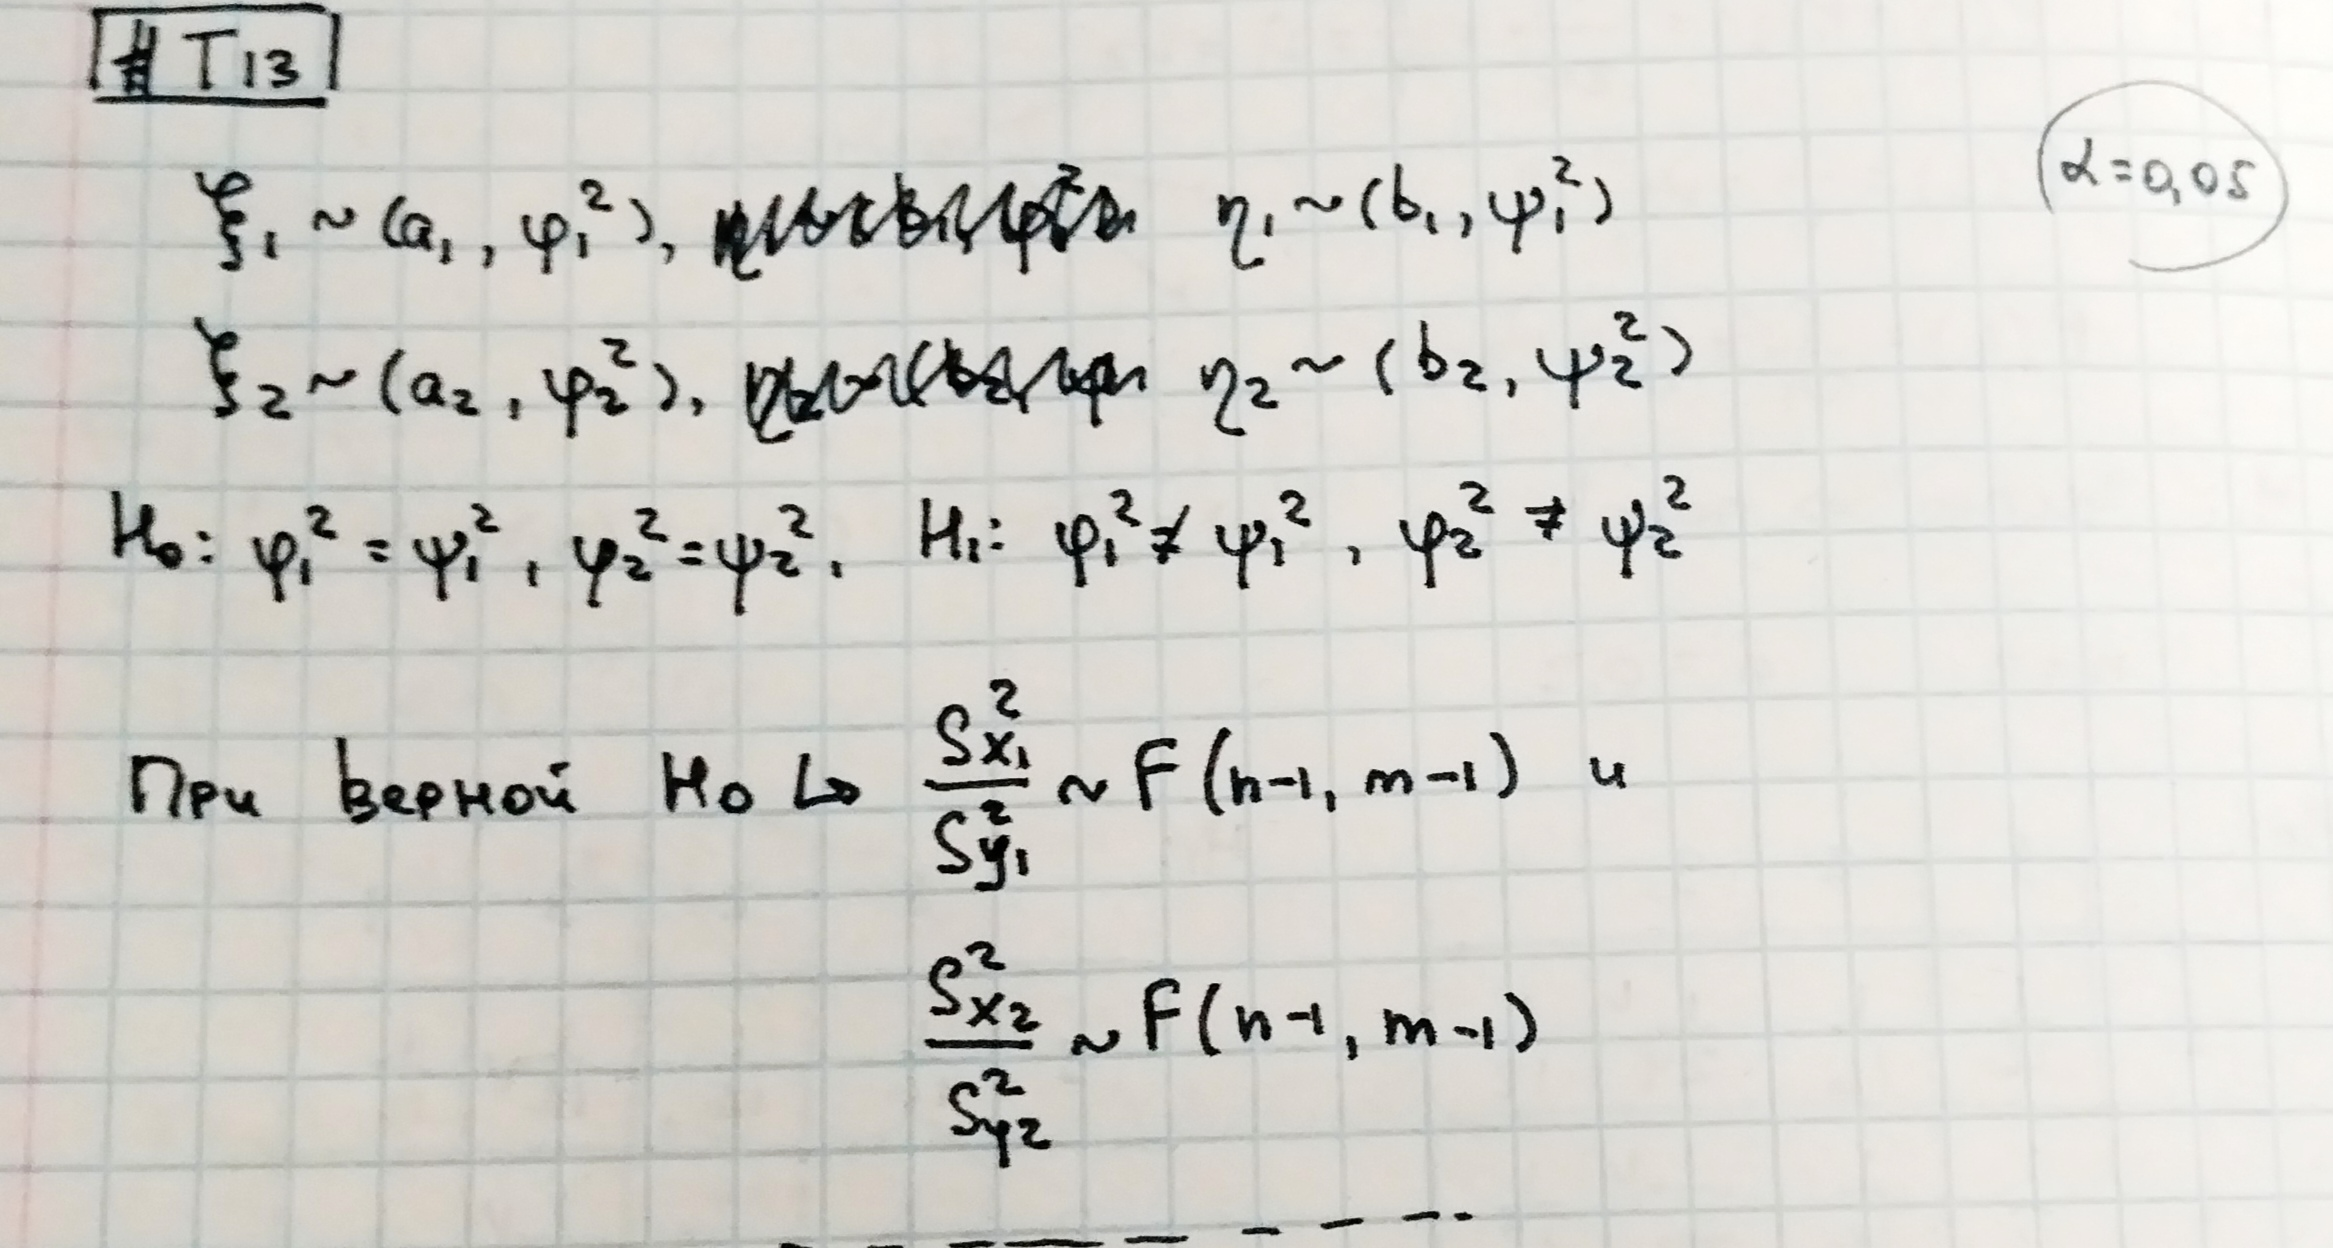

In [2]:
Image("pics/task_13_1.jpg")

In [3]:
from scipy.stats import f

# Выборки
group1_length_std = 5.722
group2_length_std = 6.161
group1_width_std = 4.612
group2_width_std = 5.055
group1_size = 139
group2_size = 1000

# Считаем F-статистику
f_statistic_length = group1_length_std**2 / group2_length_std**2
f_statistic_width = group1_width_std**2 / group2_width_std**2

# Уровень значимости
alpha = 0.05

# Степени свободы
degrees_of_freedom1 = group1_size - 1
degrees_of_freedom2 = group2_size - 1

# Критические значения
f_critical_lower = f.ppf(alpha / 2, degrees_of_freedom1, degrees_of_freedom2)
f_critical_upper = f.ppf(1 - alpha / 2, degrees_of_freedom1, degrees_of_freedom2)

# Output results
print(f"F-статистика (ширина): {f_statistic_length:.3f}")
print(f"F-статистики (длина) {f_statistic_width:.3f}")
print(f"Критические значения: [{f_critical_lower:.3f}, {f_critical_upper:.3f}]")


F-статистика (ширина): 0.863
F-статистики (длина) 0.832
Критические значения: [0.767, 1.272]


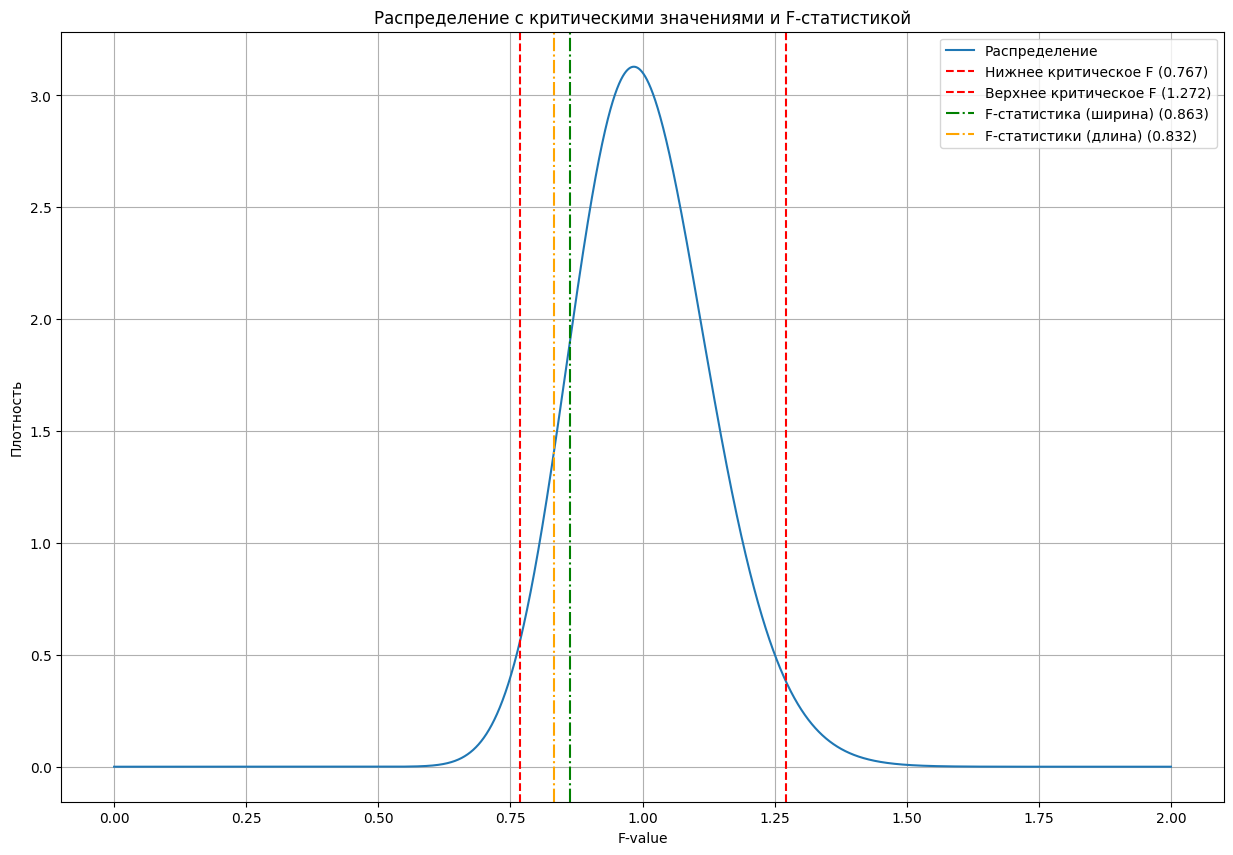

P-value (Length): 1.7272
P-value (Width): 1.8268


In [9]:
# Считаем p_value
p_value_length = f.sf(f_statistic_length, degrees_of_freedom1, degrees_of_freedom2) * 2
p_value_width = f.sf(f_statistic_width, degrees_of_freedom1, degrees_of_freedom2) * 2


x_values = np.linspace(0, 2, 10000)
y_values = f.pdf(x_values, degrees_of_freedom1, degrees_of_freedom2)

plt.figure(figsize=(15, 10))
plt.plot(x_values, y_values, label='Распределение')
plt.axvline(x=f_critical_lower, color="red", linestyle='--', label=f'Нижнее критическое F ({f_critical_lower:.3f})')
plt.axvline(x=f_critical_upper, color="red", linestyle='--', label=f'Верхнее критическое F ({f_critical_upper:.3f})')
plt.axvline(x=f_statistic_length, color="green", linestyle='-.', label=f'F-статистика (ширина) ({f_statistic_length:.3f})')
plt.axvline(x=f_statistic_width, color="orange", linestyle='-.', label=f'F-статистики (длина) ({f_statistic_width:.3f})')

plt.title('Распределение с критическими значениями и F-статистикой')
plt.xlabel('F-value')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.show()


print(f"P-value (Length): {p_value_length:.4f}")
print(f"P-value (Width): {p_value_width:.4f}")



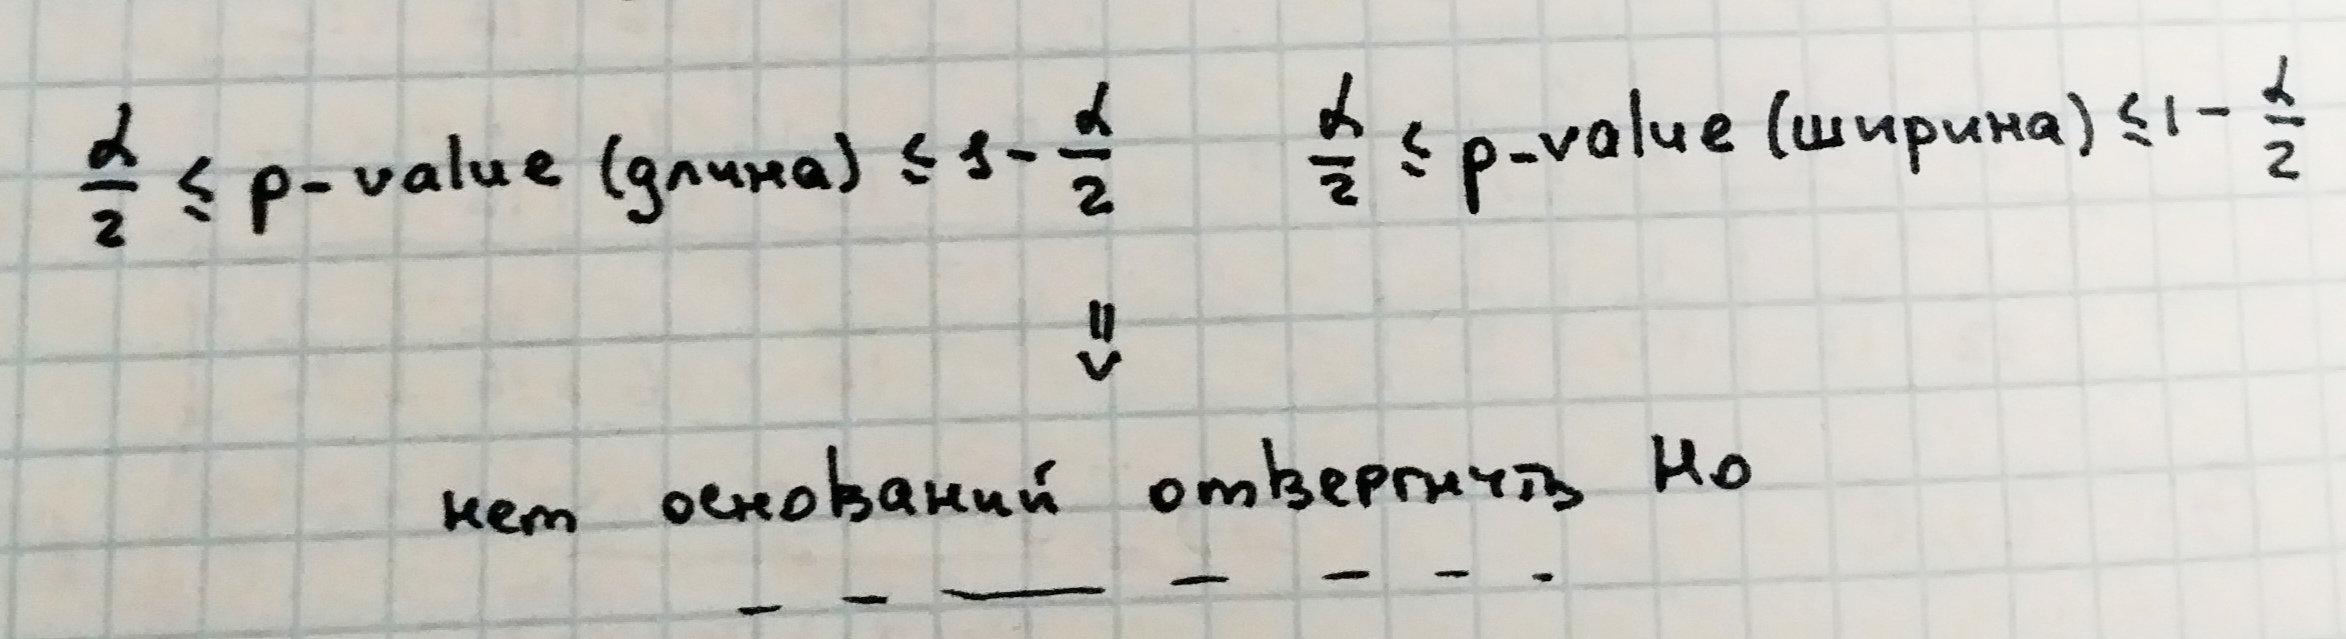

In [5]:
Image("pics/task_13_2.jpg")

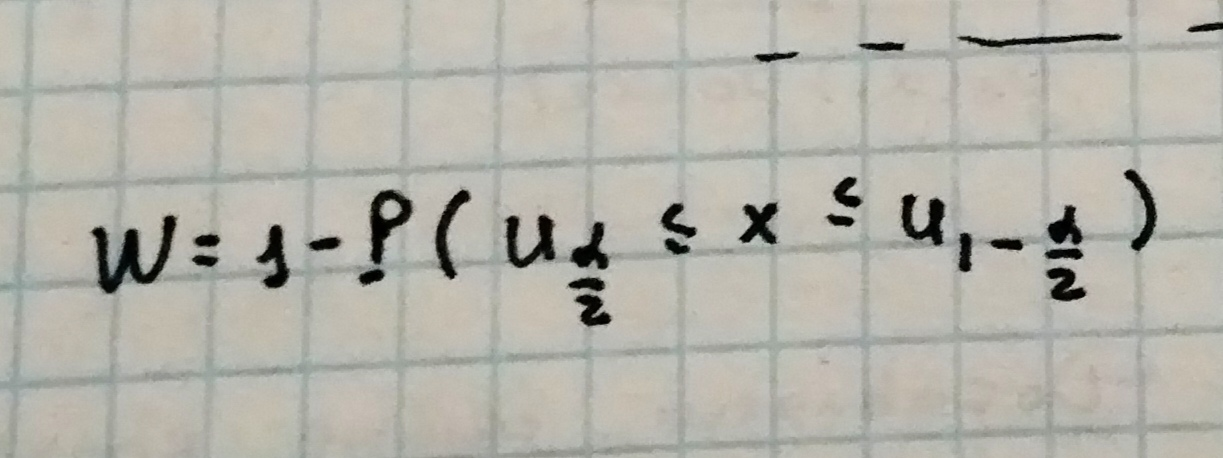

In [6]:
Image("pics/task_13_3.jpg")

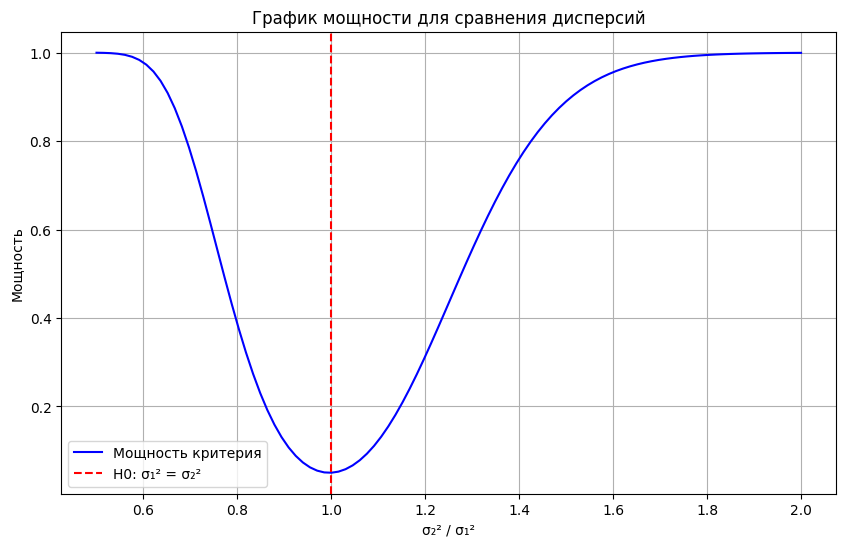

In [10]:
# Посчитаем мощность
variance_ratios = np.linspace(0.5, 2, 100) # Range of variance ratios (group2 / group1)
power = 1 - f.cdf(f_critical_upper, degrees_of_freedom1, degrees_of_freedom2, scale=variance_ratios) + f.cdf(f_critical_lower, degrees_of_freedom1, degrees_of_freedom2, scale=variance_ratios)


plt.figure(figsize=(10, 6))
plt.plot(variance_ratios, power, label="Мощность критерия", color="blue")
plt.axvline(x=1, color="red", linestyle="--", label="H0: σ₁² = σ₂²")
plt.xlabel("σ₂² / σ₁²")
plt.ylabel("Мощность")
plt.title("График мощности для сравнения дисперсий")
plt.legend()
plt.grid(True)
plt.show()
